Using tenserflow like a numpy.

In [27]:
import tensorflow as tf

t=tf.constant([[1.,2.,3.],[4.,5.,6.]])
t

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [7]:
print(t.shape)
print(t.dtype)
t[:,1:]

(2, 3)
<dtype: 'float32'>


<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 3.],
       [5., 6.]], dtype=float32)>

In [11]:
t+10
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

Custom loss function in keras.

WE use Huber loss function for ouer data ser that have many outliers where mena absolute eroor wont penelize big errors as much as mean square error.
Huber loss function is quadratic for smal errors( smaller than δ typically 1) and linear for big errors ( larger than δ).

In [12]:
def huber_fn(y_true,y_pred):
    error=y_true-y_pred
    is_small_error=tf.abs(error)<1
    squered_loss=tf.square(error)/2
    linear_loss=tf.abs(error)-0.5
    return tf.where(is_small_error,squered_loss,linear_loss)

If you want other treshold you need to implement class method with congigure function.

In [13]:
class HuberLoss(tf.keras.losses.Loss):
    def __init__(self,treshold=1.0, **kwargs):
        self.treshold=treshold
        super().__init__(**kwargs)

    def call(self,y_true,y_pred):
        error=y_true-y_pred
        is_small_error=tf.abs(error)<1
        squered_loss=tf.square(error)/2
        linear_loss=tf.abs(error)-0.5
        return tf.where(is_small_error,squered_loss,linear_loss)
    
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'treshold':self.treshold}

Custom Metrics in keras.

It wroks like that:
- for each batch during training Keras will compute this metric and keep track of its meansince the begining  of the epoch.
- most of the time it's correct to compute the metric on the batch level and average it over the epoch.
- But in for example binary classification precision (true positive/ all positive predictions) to avoid miscalculation you need an objective that keeps track of true positives, false positives and false negatives over the epoch and compute precision only at the end of the epoch.
```python
precision = tf.keras.metrics.Precision()
```

In [6]:
precision=tf.keras.metrics.Precision()
(precision([0, 1, 1, 1, 0, 1, 0, 1],[1, 1, 0, 1, 0, 1, 0, 1]))

<tf.Tensor: shape=(), dtype=float32, numpy=0.800000011920929>

The problem shown below is that we are computing precision on each batch and averaging it over the epoch which is not correct.

If we have in first batch five positive predictions and one is incorrect we have precison of 0.8.
In the second batch we have three positive and all are incorrect so precison is 0. So the mean of the two batches is 0.4. Wich is wrong beceasue we have 4 true positives over 8 positive predictions so the real precision is 0.5. 

That's why we need to use the class method that keeps track of true positives and false positives over the epoch.

In [7]:
precision([0, 1, 0, 0, 1, 0, 1, 1], [1, 0, 1, 1, 0, 0, 0, 0])

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

Example of custom metric with using Huber loss function with custom treshold delta.

In [11]:
class HuberMetric(tf.keras.metrics.Metric):
    def __init__(self,threshold=1.0,**kwargs):
        super().__init__(**kwargs)
        self.threshold=1.0
        self.huber_fn=HuberLoss(threshold)
        self.total=self.add_weight('total',initializer='zeros')# we use add_weight to create variables to keep track of the metric's state 
        self.count=self.add_weight('count',initializer='zeros')

    def update_state(self,y_true,y_pred,sample_weight=None):
        sample_metrics=self.huber_fn(y_true,y_pred)
        self.total.assign_add(tf.reduce_sum(sample_metrics))
        self.count.assign_add(tf.cast(tf.size(y_true),tf.float32))

    def result(self):
        return self.total/self.count
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'threshold':self.threshold}

### **Custom layers in keras.**

Below is simple example of Dense layer:

In [13]:
class MyDenseLayer(tf.keras.layers.Layer):
    def __init__(self, units,activation=None,**kwargs):
        super.__init__(**kwargs) # calling parent constructor and passing to it kwargs
        self.units=units
        self.activation=tf.keras.activations.get(activation) # this line converts activation argument to proper activation function
    
    def build(self,batch_input_shape):
        # this method creates the layers variebles by calling add_weight method fo each weight
        # the build method is called the first time the layer is used
        # At that poin Keras will know the shape of this layer's inputs and it will pass it to build()
        # method which is necessary to create some of the weights
        self.kernel=self.add_weight(name='kernel',shape=[batch_input_shape[-1],self.units], 
                                    initializer='zeros')
        self.bias=self.add_weight(name='bias',shape=[self.units], initializer='zeros')

    def call(self,X): 
        # method performs the deired operations 
        # in this case we compute the matrix multiplication of the inputs X and layer's kernel
        # we add the bias vector and apply the activation functin to the result 
        # this give us the output of the layer
        return self.activation(X@self.kernal+self.bias)
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'units':self.units, 
                'activation': tf.keras.activations.serialize(self.activation)}

### **CUSTOM MODEL**

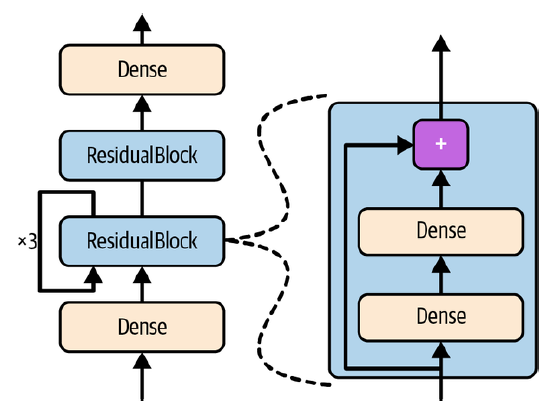

In [ ]:
# Creating residual block layer that conatins other layers 
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self,n_layers, n_neurons, **kwargs):
        super().__init__(**kwargs)
        self.hidden=[tf.keras.layers.Dense(n_neurons,activation='relu', kernel_initializer='he_normal')
                     for i in range(n_layers)]
        # it atomaticaly detects that hidden attribute conatins other trackable objects in this case 
        # layers so their variebles are atomatically added to this layers variables lists
    
    def call(self,inputs):
        Z=inputs
        for layer in self.hidden:
            Z=layer(Z)
        return inputs + Z

In [ ]:
class ResidualReggressor(tf.keras.Model):
    def __init__(self,output_dim,**kwargs):
        super().__init__(**kwargs)
        self.hidden1=tf.keras.layers.Dense(30,activation='relu',kernel_initializer='he_normal')
        
        self.block1=ResidualBlock(2,30)
        self.block2=ResidualBlock(2,30)
        self.out=tf.keras.layers.Dense(output_dim)

    def call(self,inputs):
        Z=self.hidde1(inputs)
        for _ in range(1+3):
            Z=self.block1(Z)
        Z+self.block2(Z)
        return self.out(Z)


#### **Losses, Metric based on Model Internal**

Adding loss and metrics basedo on model internal calculation such as the weights or activations of its hidden layers. 
It's useful for regulatization losses such as L1 and L2 regularization.

Ypu want to pass the result of compute loss to add_loss() method of the model.

In [ ]:
class ReconstructingRegressor(tf.keras.Model):
    def __init__(self,output_dim,**kwargs):
        # creating DNN with 5 dense hidden layers
        super.__init__(**kwargs)
        self.hidden=[tf.keras.layers.Dense(30, activation='relu', kernel_initializer='he_normal')
                     for _ in range(5)]
        
        self.out=tf.keras.layers.Dense(output_dim) # one output layer 
        self.reconstruction_mean=tf.keras.metric.Mean(name='reconstruction_error')# we keep track of reconstruction error

    def build(self,batch_input_shape):
        # we create an extra dense layer to reconstruct the inputs of the model
        # it must be done here beceasue number of units must be equal to the number of inputs
        n_inputs=batch_input_shape[-1]
        self.reconstruct=tf.keras.layers.Dense(n_inputs)

    def call(self, inputs,training=False):
        Z=inputs
        for layer in self.hidden: # prcessing the inupts trough all dense layers 
            Z=layer(Z)
        reconstruction=self.reconstruct(Z)
        recon_loss=tf.reduce_mean(tf.square(reconstruction-inputs))# computing the reconstruction loss
        self.add_loss(0.05*recon_loss) # we scale it down just to make sure that it wont dominate the main loss
        if training:
            result=self.reconstruction_mean(recon_loss)
            self.add_metric(result)
        return self.out(Z) # passing the error to output layer

### **Computing Gradients Using Autodiff**

In [ ]:
def f(w1,w2):
    return 3*w1**2+2*w1*w2

In [21]:
# reverse mode autodiff

w1,w2=tf.Variable(5.),tf.Variable(3.)
with tf.GradientTape() as tp:
    z=f(w1,w2)
gradients=tp.gradient(z,[w1,w2])
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

If you want to call gradient wice you will get an exception so if you want to do that you need to use persistent= True parameter and delete the tape when you finish using it.

To stop backpropagation you can use stop_gradient() function.
The function returns its inputs during the forward pass but it treats them as constant during the backward pass so no gradient will be propagated through these tensors.

For unstable gradients you can use decorator @tf.custom_gradient to define your own gradient for some function. Then you have to return the value of the function and a function that computes the gradient.

Example :
```python
@tf.custom_gradient
def my_softplus(z):
    def my_softplus_gradients(grads): # grads = backprop'ed from upper layers
        return grads * (1 - 1 / (1 + tf.exp(z))) # stable grads of softplus
    result = tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)
    return result, my_softplus_gradients

```

### **Custom Training Loops**

In some cases the fit() method may not be flexible emough for what we need.

In [29]:
from tensorflow import keras
fashion_mnist=keras.datasets.fashion_mnist
(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist.load_data()

print(X_train_full.shape)
print(X_train_full.dtype)
X_valid,X_train=X_train_full[:5000]/255.0,X_train_full[5000:]/255.0
y_valid,y_train=y_train_full[:5000],y_train_full[5000:]

class_names=["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

(60000, 28, 28)
uint8


In [30]:
# simple mdoel
l2_reg = tf.keras.regularizers.l2(0.05)
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(30, activation="relu",
                             kernel_initializer="he_normal",
                            kernel_regularizer=l2_reg),
        tf.keras.layers.Dense(1, kernel_regularizer=l2_reg)
])

In [31]:
import numpy as np
# function that randomly sample a batch of instance for training set
def random_batch(X,y,batch_size=32):
    idx=np.random.randint(len(X),size=batch_size)
    return X[idx],y[idx]

In [32]:
# function for displaying training process 

def print_status_bar(step, total, loss, metrics=None):
    metrics='-'.join([f"{m.name}: {m.result():.4f}" for m in [loss]+(metrics or [])])
    end=""if step<total else'\n'
    print(f"\r{step}/{total}-"+metrics, end=end)

In [39]:
# defining some paramters 

n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
loss_fn = tf.keras.losses.MeanSquaredError()
mean_loss = tf.keras.metrics.Mean(name="mean_loss")
metrics = [tf.keras.metrics.MeanAbsoluteError()]


In [42]:
# custom loop 

for epoch in range(1,n_epochs+1):
    print("Epoch{}/{}".format(epoch,n_epochs))


    for step in range(1,n_steps+1):

        X_batch,y_batch=random_batch(X_train,y_train)

        with tf.GradientTape() as tape:
            y_pred=model(X_batch,training=True)
            main_loss=tf.reduce_mean(loss_fn(y_batch,y_pred))
            loss=tf.add_n([main_loss]+model.losses)

        gradients=tape.gradient(loss,model.trainable_variables)
        optimizer.apply_gradients(zip(gradients,model.trainable_variables))
        mean_loss(loss)

        for metric in metrics:
            metric(y_batch,y_pred)
        print_status_bar(step,n_steps,mean_loss,metrics)

    for metric in [mean_loss]+metrics:
        metric.reset_state()
    

Epoch1/5
1718/1718-mean_loss: 8.6136-mean_absolute_error: 2.4982
Epoch2/5
1718/1718-mean_loss: 8.2579-mean_absolute_error: 2.4946
Epoch3/5
1718/1718-mean_loss: 8.3018-mean_absolute_error: 2.5025
Epoch4/5
1718/1718-mean_loss: 8.2549-mean_absolute_error: 2.4940
Epoch5/5
1718/1718-mean_loss: 8.3041-mean_absolute_error: 2.5057
